In [4]:
import warnings                                       #NEGLECT UNNESSASARY WARNINGS
import os                                             # INPUT FILES ARE AVAILABLE IN READ_ONLY "../INPUT/" DIRECTORY
for dirname, _, filenames in os.walk('/kaggle/input'): #THIS IS EXAMPLE WILL ITERATE THROUGH ALL FILES IN /kaggle/input/data directory and subdirectories
    for filename in filenames:
        print(os.path.join(dirname, filename))

#FOR ALL THE CODE
import pandas as pd             # DATA PROCESSING AND ACCESS, CSV FILE I/O             
import numpy as np              #FOR NUMERICAL OPERATIONS IE, LINEAR ALGEBRA AND MORE
import matplotlib.pyplot as plt #FOR EXTRA POLATE VALUES
import seaborn as sns           #FOR REPRESENT THE PLOTS

import nltk                             #CLEANING THE DATA
from nltk.corpus import stopwords       #GETTING ALL THE STOPWORDS
import re

from sklearn.feature_extraction.text import CountVectorizer   #VECTORIZE THE REMAINING CATEGORICAL DATA 
from sklearn.model_selection import train_test_split          #FOR SPLITTING DATA FOR TRAINIG AND TESTING MODEL

from sklearn.linear_model import LogisticRegression          #MAKING DIFF MODEL
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

#CALCULATION OF ACCURACY SCORES OF THE MODEL
from sklearn.metrics import classification_report, f1_score, recall_score, roc_auc_score 

warnings.filterwarnings('ignore')   #COMMAND WHEN WARNINGS OCCUR

# 1.Data

In [5]:
data = pd.read_csv("spam.csv", encoding = 'latin_1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
data = data.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1)  #REMOVE THE LESS SIGNIFICANT FEATURES
data.columns = ['label', 'message']                                #RENAME THE PRESENT FEATURES
data.info()                                                        #LETS SEE MISSINGS OR NULL VALUES AND DATA TYPES

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


##### INSIDE DATA:: SPAM AND HAM DISTRIBUTIONS

In [8]:
data['label'] = data['label'].map({'spam': 1, 'ham': 0}) #convert spams into 1 and ham's into 0

data['label'].value_counts()                             #see how many are present in the data

label
0    4825
1     747
Name: count, dtype: int64

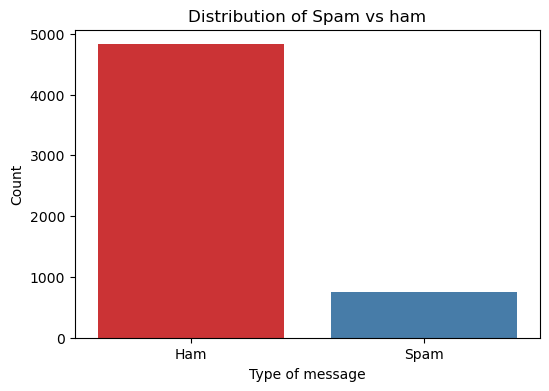

In [9]:
counts = data['label'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette='Set1')
plt.title('Distribution of Spam vs ham')
plt.xlabel('Type of message')
plt.ylabel('Count')
plt.xticks([0,1], ['Ham', 'Spam'])
plt.show()

# 2.DATA PREPROCESSING

In [10]:
stop_words = set(stopwords.words('english'))
def  preprocess_text(text):
    text = text.lower()                 #ALL THE TEXT IN LOWER CASE 
    text = re.sub(r'\d+', '', text)     #TEXT DONOT HAVE DIGITS 
    text = re.sub(r'[^\w\s]', '', text) #REMOVED ALL NO_WORDS LIKE , . ; AND MORE
    text = ' '.join([word for word in text.split() if word not in stop_words]) # ALL STOPWORDS ARE REMOVED
    return text                         #FINAL MODIFIED TEXT


In [11]:
data['clean_message'] = data['message'].apply(preprocess_text)
data[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


#### VECTORIZING THE TEXT TO VECTORS

In [12]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['clean_message'])
X.shape

(5572, 8467)

# 3.SPLITTING DATA:: TRAINIG AND TESTING DATA

In [13]:
X_train, X_test, y_train, y_test  = train_test_split(X, data['label'], test_size =0.2, random_state=42)
print(X_train.shape, X_test.shape)


(4457, 8467) (1115, 8467)


# 4.MODEL MAKING

##### NAMING MODELS , TRAINING THEM AND TESTING

In [14]:
models ={
    "NavieBayes:" : MultinomialNB().fit(X_train, y_train),
    "LogisticRegression" : LogisticRegression(max_iter=1000).fit(X_train, y_train),
    "SVC"  : SVC(kernel='linear').fit(X_train, y_train)
}

##### Testing the model and get scores of the model

In [15]:
comparision_data = []
for name, model in models.items():

    y_pred = model.predict(X_test)
    y_pred_tr = model.predict(X_train)

    report_test = classification_report(y_test, y_pred, output_dict=True)
    report_train = classification_report(y_train, y_pred_tr, output_dict=True)

    for label in report_test.keys():
        if label not in ["accuracy", "macro avg", "weighted avg"]:
            comparision_data.append({
                'Model': name,
                'Dataset': 'Test',
                'Label': label,
                'Precision': report_test[label]['precision'],
                'Recall': report_test[label]['recall'],
                'F1-score': report_test[label]['f1-score'],
                'Accuracy': report_test['accuracy']
            })
            comparision_data.append({
                'Model': name,
                'Dataset': 'Train',
                'Label': label,
                'Precision': report_train[label]['precision'],
                'Recall': report_train[label]['recall'],
                'F1-score': report_train[label]['f1-score'],
                'Accuracy': report_train['accuracy']
            })

comparision_df = pd.DataFrame(comparision_data)

comparision_df

,Model,Dataset,Label,Precision,Recall,F1-score,Accuracy
0,NavieBayes:,Test,0,0.984359,0.978238,0.981289,0.967713
1,NavieBayes:,Train,0,0.995339,0.995855,0.995597,0.992372
2,NavieBayes:,Test,1,0.865385,0.900000,0.882353,0.967713
3,NavieBayes:,Train,1,0.973109,0.969849,0.971477,0.992372
4,LogisticRegression,Test,0,0.973764,1.000000,0.986708,0.976682
5,LogisticRegression,Train,0,0.994588,0.999741,0.997158,0.995064
6,LogisticRegression,Test,1,1.000000,0.826667,0.905109,0.976682
7,LogisticRegression,Train,1,0.998267,0.964824,0.981261,0.995064
8,SVC,Test,0,0.973631,0.994819,0.984111,0.972197
9,SVC,Train,0,0.999741,1.000000,0.999870,0.999776


#### Comparision btw models

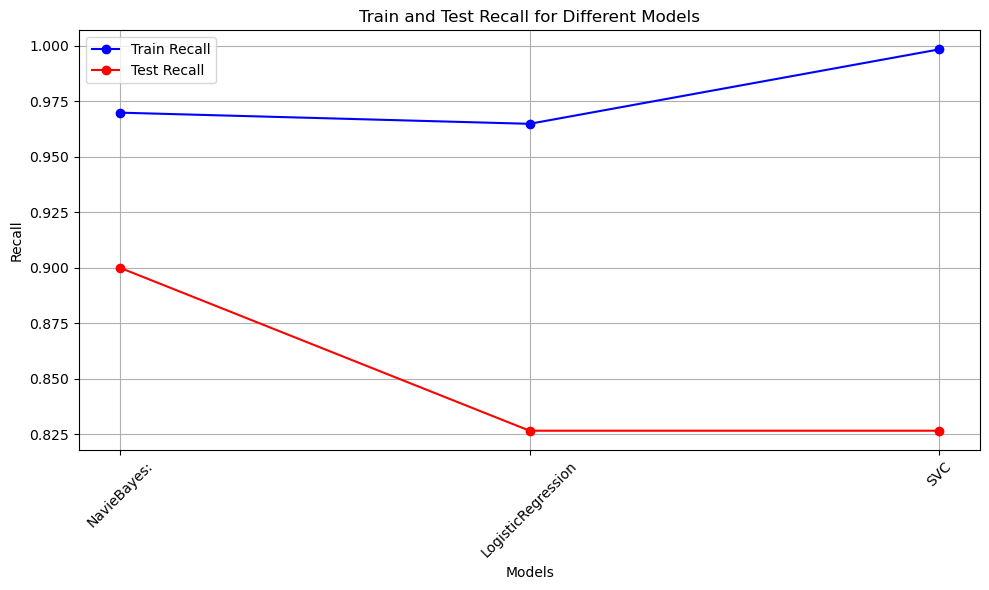

In [16]:
recall_scores_test = []
recall_scores_train = []
model_names = []                        #INTIALIZING ALL THE SETS

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_tr = model.predict(X_train)

    recall_test = recall_score(y_test, y_pred, average='binary')
    recall_train = recall_score(y_train, y_pred_tr, average='binary')   #MAKING THE DATA

    recall_scores_test.append(recall_test)
    recall_scores_train.append(recall_train)
    model_names.append(name)                                            #FILLING THE SETS

#REPRESSENTATION PROPS
plt.figure(figsize=(10,6))
plt.plot(model_names, recall_scores_train, marker='o', linestyle='-', color='b', label='Train Recall')
plt.plot(model_names, recall_scores_test, marker='o', linestyle='-', color='r', label='Test Recall')

#APPERANCE OF THE REPRESENTATION
plt.xlabel('Models')                                    
plt.ylabel('Recall')
plt.title('Train and Test Recall for Different Models')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()